In [36]:
from functions import *

import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
import statsmodels.api as sm

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import os
#Caminho para dados dos aglomerados
path = './Aglomerados'

import warnings
warnings.filterwarnings('ignore')

In [27]:
df =pd.read_csv('Dados/results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv('Dados/benchmark_subsample.csv', index_col='Cluster')

print('full sample description')
print(df[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members' ]].describe().round(2).T)

print('\nBenchmark subsample description')
print(benchmark_subsample[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members' ]].describe().round(2).T)


full sample description
            count    mean     std    min     25%     50%     75%      max
dist        771.0    1.75    1.00   0.14    0.94    1.64    2.37     6.87
age         771.0    8.18    0.64   6.67    7.79    8.25    8.68     9.59
FeH         771.0   -0.04    0.11  -0.37   -0.11   -0.04    0.03     0.43
Av          771.0    1.41    0.79   0.01    0.81    1.38    1.92     4.49
mass_total  771.0  544.47  447.32  61.00  245.00  413.00  678.00  3434.00
n_members   771.0  311.12  240.91  42.00  147.00  242.00  394.00  1548.00

Benchmark subsample description
            count    mean     std    min     25%     50%     75%      max
dist         94.0    0.63    0.29   0.14    0.39    0.61    0.79     1.37
age          94.0    8.24    0.57   6.74    7.80    8.31    8.63     9.58
FeH          94.0   -0.02    0.08  -0.23   -0.06   -0.03    0.01     0.18
Av           94.0    0.26    0.14   0.01    0.17    0.27    0.35     0.49
mass_total   94.0  362.59  288.40  63.00  194.00  292.0

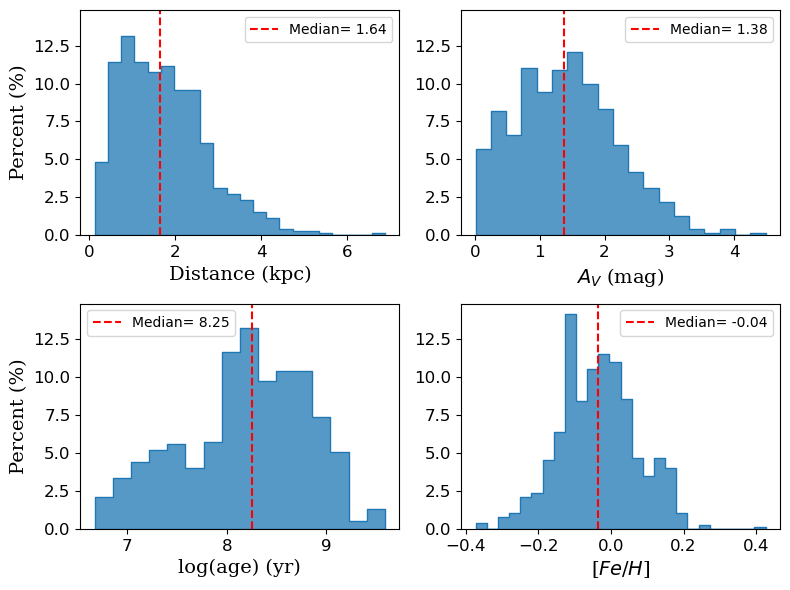

In [30]:
fig, axs = plt.subplots(2,2, figsize = (8,6), sharey=True)

sns.histplot(data=df, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=df['dist'].median(), color='r',ls='--',  label = f'Median= {df.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=df, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=df['Av'].median(), color='r',ls='--', label = f'Median= {df.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=df, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=df['age'].median(), color='r',ls='--', label = f'Median= {df.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=df, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=df['FeH'].median(), color='r',ls='--', label = f'Median= {df.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
#plt.savefig('clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()